In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path
from utils import style

# ── Palette ────────────────────────────────────────────────────────────────
NAVY   = "#0B1F3B"
TEAL   = "#0D9488"
TEAL_L = "#14B8A6"
GOLD   = "#F59E0B"
SLATE  = "#64748B"

SIZE_ORDER  = ["moderate_or_small", "large", "very_large"]
SIZE_LABELS = {
    "moderate_or_small": "Moderate\nsmall",
    "large":             "Large",
    "very_large":        "Very large",
}
SIZE_COLORS = {
    "moderate_or_small": TEAL,
    "large":             NAVY,
    "very_large":        GOLD,
}

OUT = Path("figures")
OUT.mkdir(exist_ok=True)

In [13]:
df = pd.read_csv("cluster_summary.csv")
df["size_type"] = pd.Categorical(df["size_type"], categories=SIZE_ORDER, ordered=True)

print(df["size_type"].value_counts().sort_index())

size_type
moderate_or_small    25396
large                 2663
very_large             285
Name: count, dtype: int64


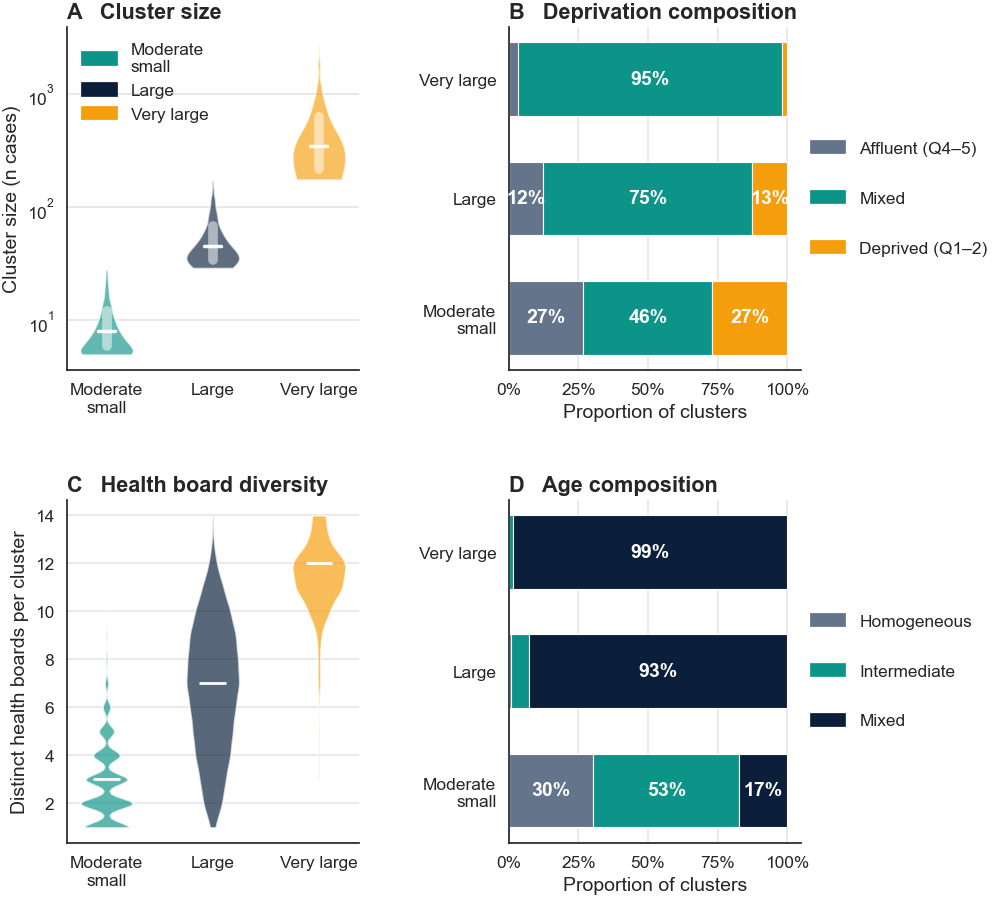

In [18]:
fig, axes = style.new_figure(
    width="slide", height_in=9, nrows=2, ncols=2,
    facecolor="white", layout="constrained",
    gridspec_kw={"hspace": 0.12, "wspace": 0.12},
    context="talk", font_scale=1.2,
)
ax_a, ax_b, ax_c, ax_d = axes.flatten()

y_pos = np.arange(len(SIZE_ORDER))   # shared positional axis for bar panels

# ── A) Cluster size — violin + IQR bar + median annotation ───────────────────
parts = ax_a.violinplot(
    [df[df["size_type"] == st]["n_cases"].values for st in SIZE_ORDER],
    positions=[1, 2, 3], showmedians=False, showextrema=False,
)
for pc, st in zip(parts["bodies"], SIZE_ORDER):
    pc.set_facecolor(SIZE_COLORS[st])
    pc.set_alpha(0.65)

for i, st in enumerate(SIZE_ORDER, 1):
    vals = df[df["size_type"] == st]["n_cases"]
    q25, q50, q75 = vals.quantile([0.25, 0.5, 0.75])
    ax_a.plot(
        [i - 0.08, i + 0.08], [q50, q50],
        color="white", lw=2.5, zorder=5
    )
    ax_a.plot(
        [i, i], [q25, q75], color="white", lw=7,
        solid_capstyle="round", zorder=4, alpha=0.5
    )
    # ax_a.annotate(
    #     f"median {q50:.0f}", xy=(i, q50), xytext=(i + 0.18, q50),
    #     color=SIZE_COLORS[st], va="center", fontweight="bold"
    # )

ax_a.set_xticks([1, 2, 3])
ax_a.set_xticklabels([SIZE_LABELS[st] for st in SIZE_ORDER])
ax_a.set_ylabel("Cluster size (n cases)")
ax_a.set_yscale("log")
ax_a.set_title("A   Cluster size", loc="left", fontweight="bold")
ax_a.grid(axis="y", alpha=0.45)

# ── B) Deprivation composition — stacked horizontal bar ──────────────────────
DEP_ORDER  = ["predominantly_affluent", "mixed_deprivation", "predominantly_deprived"]
DEP_LABELS = {
    "predominantly_affluent": "Affluent (Q4–5)",
    "mixed_deprivation":      "Mixed",
    "predominantly_deprived": "Deprived (Q1–2)",
}
DEP_COLORS = {
    "predominantly_affluent": SLATE,
    "mixed_deprivation":      TEAL,
    "predominantly_deprived": GOLD,
}

dep_ct  = pd.crosstab(df["size_type"], df["deprivation_type"],
                      normalize="index").reindex(SIZE_ORDER)
bottoms = np.zeros(len(SIZE_ORDER))
for dep in DEP_ORDER:
    vals = dep_ct[dep].values
    ax_b.barh(y_pos, vals, left=bottoms, height=0.62,
              color=DEP_COLORS[dep], edgecolor="white", linewidth=0.8)
    for j, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 0.08:
            ax_b.text(
                b + v / 2, j, f"{v:.0%}",
                ha="center", va="center",
                fontweight="bold", color="white"
            )
    bottoms += vals

ax_b.set_yticks(y_pos)
ax_b.set_yticklabels([SIZE_LABELS[s] for s in SIZE_ORDER])
ax_b.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax_b.set_xlabel("Proportion of clusters")
ax_b.set_title("B   Deprivation composition", loc="left", fontweight="bold")
ax_b.grid(axis="x", alpha=0.4)

# ── C) Health board diversity — violin ───────────────────────────────────────

parts = ax_c.violinplot(
    [df[df["size_type"] == st]["n_health_boards"].values for st in SIZE_ORDER],
    positions=[1, 2, 3], showmedians=True, showextrema=False,
)
for pc, st in zip(parts["bodies"], SIZE_ORDER):
    pc.set_facecolor(SIZE_COLORS[st])
    pc.set_alpha(0.68)
parts["cmedians"].set_color("white")
parts["cmedians"].set_linewidth(2)

ax_c.set_xticks([1, 2, 3])
ax_c.set_xticklabels([SIZE_LABELS[st] for st in SIZE_ORDER])
ax_c.set_ylabel("Distinct health boards per cluster")
ax_c.set_title("C   Health board diversity", loc="left", fontweight="bold")
ax_c.grid(axis="y", alpha=0.4)
# for i, st in enumerate(SIZE_ORDER, 1):
#     med = df[df["size_type"] == st]["n_health_boards"].median()
#     ax_c.text(
#         i + 0.12, med, f"{med:.0f} median", va="center",
#         color=SIZE_COLORS[st], fontweight="bold"
#     )


# ── D) Age composition — stacked horizontal bar ───────────────────────────────
AGE_ORDER  = ["age_homogeneous", "intermediate_age_mix", "age_mixed"]
AGE_LABELS = {
    "age_homogeneous":      "Homogeneous",
    "intermediate_age_mix": "Intermediate",
    "age_mixed":            "Mixed",
}
AGE_COLORS = [SLATE, TEAL, NAVY]

age_ct   = pd.crosstab(df["size_type"], df["age_type"],
                       normalize="index").reindex(SIZE_ORDER)
bottoms  = np.zeros(len(SIZE_ORDER))
for ag, col in zip(AGE_ORDER, AGE_COLORS):
    vals = age_ct[ag].values
    ax_d.barh(y_pos, vals, left=bottoms, height=0.62,
              color=col, edgecolor="white", linewidth=0.8)
    for j, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 0.08:
            ax_d.text(
                b + v / 2, j, f"{v:.0%}",
                ha="center", va="center",
                fontweight="bold", color="white"
            )
    bottoms += vals

ax_d.set_yticks(y_pos)
ax_d.set_yticklabels([SIZE_LABELS[s] for s in SIZE_ORDER])
ax_d.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax_d.set_xlabel("Proportion of clusters")
ax_d.set_title("D   Age composition", loc="left", fontweight="bold")
ax_d.grid(axis="x", alpha=0.4)


# ── Legends ───────────────────────────────────────────────────────────────────
size_handles = [
    mpatches.Patch(color=SIZE_COLORS[st],
                   label=f"{SIZE_LABELS[st]}")
    for st in SIZE_ORDER
]
age_handles = [
    mpatches.Patch(color=col, label=AGE_LABELS[ag])
    for ag, col in zip(AGE_ORDER, AGE_COLORS)
]
dep_handles = [
    mpatches.Patch(color=DEP_COLORS[d], label=DEP_LABELS[d])
    for d in DEP_ORDER
]

ax_a.legend(handles=size_handles, loc="upper left", frameon=False)

ax_d.legend(
    handles=age_handles, loc="center left",
    bbox_to_anchor=(1.01, 0.5), labelspacing=2,
    borderaxespad=0, frameon=False
)
ax_b.legend(
    handles=dep_handles,  loc="center left",
    bbox_to_anchor=(1.01, 0.5), labelspacing=2,
    borderaxespad=0, frameon=False
)

fig.savefig(OUT / "cluster_composition_summary.png", dpi=300, bbox_inches="tight")
fig.savefig(OUT / "cluster_composition_summary.svg", dpi=300, bbox_inches="tight")
plt.show()